<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_5/datasaurus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Funções auxiliares

In [2]:
def cohens_d(first_group, second_group):
    first_group = np.asarray(first_group)
    second_group = np.asarray(second_group)

    n_first = len(first_group)
    n_second = len(second_group)
    pooled_variance = (
        (n_first - 1) * first_group.var(ddof=1)
        + (n_second - 1) * second_group.var(ddof=1)
    ) / (n_first + n_second - 2)
    pooled_standard_deviation = np.sqrt(pooled_variance)

    return (first_group.mean() - second_group.mean()) / (
        pooled_standard_deviation
    )

In [3]:
def compare_stats(data, group1, group2):
    df1 = data[data["dataset"] == group1]
    df2 = data[data["dataset"] == group2]

    columns = pd.MultiIndex.from_tuples(
        [
            ("x", group1.capitalize()),
            ("x", group2.capitalize()),
            ("y", group1.capitalize()),
            ("y", group2.capitalize()),
        ]
    )

    comparison = pd.DataFrame(
        [
            [
                df1["x"].mean(),
                df2["x"].mean(),
                df1["y"].mean(),
                df2["y"].mean(),
            ],
            [
                df1["x"].median(),
                df2["x"].median(),
                df1["y"].median(),
                df2["y"].median(),
            ],
            [
                df1["x"].var(ddof=1),
                df2["x"].var(ddof=1),
                df1["y"].var(ddof=1),
                df2["y"].var(ddof=1),
            ],
            [
                df1["x"].std(ddof=1),
                df2["x"].std(ddof=1),
                df1["y"].std(ddof=1),
                df2["y"].std(ddof=1),
            ],
        ],
        index=["Média", "Mediana", "Variância", "Desvio-padrão"],
        columns=columns,
    )

    return comparison

In [4]:
def plot_pair(data, datasets):
    sns.set_theme(style="darkgrid", context="notebook")
    subset = data[data["dataset"].isin(datasets)]
    grid = sns.FacetGrid(
        subset,
        col="dataset",
        col_wrap=2,
        height=4,
        sharex=True,
        sharey=True,
    )
    grid.map_dataframe(
        sns.scatterplot,
        x="x",
        y="y",
        s=20,
        linewidth=0,
    )
    grid.set(xlim=(0, 100), ylim=(0, 100))
    grid.set_axis_labels("x", "y")
    grid.set_titles("{col_name}")
    plt.show()

### Datasaurus

In [5]:
datasaurus_url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
    "main/data/2020/2020-10-13/datasaurus.csv"
)

datasaurus_df = pd.read_csv(datasaurus_url)

In [6]:
datasaurus_df.shape

(1846, 3)

In [7]:
datasaurus_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   str    
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), str(1)
memory usage: 43.4 KB


In [8]:
datasaurus_df.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [9]:
datasaurus_df["dataset"].value_counts()

dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

In [10]:
star = datasaurus_df.loc[
    datasaurus_df["dataset"] == "star",
    ["x", "y"],
]

dino = datasaurus_df.loc[
    datasaurus_df["dataset"] == "dino",
    ["x", "y"],
]

## Média aritmética

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i $$

Onde:
*   $\bar{x}$ representa a média amostral;
*   $n$ é o número de observações no conjunto de dados;
*   $x_i$ representa cada valor individual;
*   $\sum$ indica a soma dos valores.

In [11]:
print(f"Média de dino: {dino['x'].mean():.3f}, {dino['y'].mean():.3f}")
print(f"Média de star: {star['x'].mean():.3f}, {star['y'].mean():.3f}")

Média de dino: 54.263, 47.832
Média de star: 54.267, 47.840


## Mediana

Para um conjunto de dados ordenado $x_1, x_2, \dots, x_n$:

Se $n$ é ímpar:
$$ \text{Mediana} = x_{\frac{n+1}{2}} $$

Se $n$ é par:
$$ \text{Mediana} = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2} + 1}}{2} $$

Onde:
*   $n$ é o número de observações no conjunto de dados;
*   $x$ representa os valores individuais ordenados em ordem crescente.

In [12]:
print(f"Mediana de dino: {dino['x'].median():.3f}, {dino['y'].median():.3f}")
print(f"Mediana de star: {star['x'].median():.3f}, {star['y'].median():.3f}")

Mediana de dino: 53.333, 46.026
Mediana de star: 56.535, 50.111


## Variância

$$ s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 $$

Onde:
*   $s^2$ representa a variância amostral;
*   $n$ é o número de observações no conjunto de dados;
*   $x_i$ representa cada valor individual;
*   $\bar{x}$ representa a média amostral;
*   $\sum$ indica a soma dos desvios quadráticos.

In [13]:
print(f"Variância de dino: {dino['x'].var(ddof=1):.3f}, {dino['y'].var(ddof=1):.3f}")
print(f"Variância de star: {star['x'].var(ddof=1):.3f}, {star['y'].var(ddof=1):.3f}")

Variância de dino: 281.070, 725.516
Variância de star: 281.198, 725.240


## Desvio-padrão

$$ s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2} $$

Onde:
*   $s$ representa o desvio-padrão amostral;
*   $n$ é o número de observações no conjunto de dados;
*   $x_i$ representa cada valor individual;
*   $\bar{x}$ representa a média amostral;
*   $\sum$ indica a soma dos desvios quadráticos.

In [14]:
print(f"Desvio-padrão de dino: {dino['x'].std(ddof=1):.3f}, {dino['y'].std(ddof=1):.3f}")
print(f"Desvio-padrão de star: {star['x'].std(ddof=1):.3f}, {star['y'].std(ddof=1):.3f}")

Desvio-padrão de dino: 16.765, 26.935
Desvio-padrão de star: 16.769, 26.930


## Cohen’s d: o detector final?

Depois de tantas medidas quase iguais, poderíamos querer um único número simples e poderoso para decidir se há uma diferença relevante. Vamos experimentar Cohen’s d separadamente em `x` e em `y` e, por enquanto, tratá-lo como esse detector final.

$$ d = \frac{\bar{x}_1 - \bar{x}_2}{s_p} $$

Onde o desvio-padrão combinado ($s_p$) é calculado como:

$$ s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}} $$

Onde:
*   $d$ representa Cohen’s d;
*   $\bar{x}_1$ e $\bar{x}_2$ são as médias amostrais dos grupos;
*   $s_p$ é o desvio-padrão agrupado;
*   $s_1^2$ e $s_2^2$ são as variâncias amostrais;
*   $n_1$ e $n_2$ são os tamanhos das amostras.

In [15]:
d_x = abs(cohens_d(dino["x"], star["x"]))
d_y = abs(cohens_d(dino["y"], star["y"]))

print(f"Cohen’s d em x: {d_x:.4f}")
print(f"Cohen’s d em y: {d_y:.4f}")

Cohen’s d em x: 0.0002
Cohen’s d em y: 0.0003


In [16]:
dino_star_comparison = compare_stats(datasaurus_df, "dino", "star")
display(dino_star_comparison.round(3))

x                 y         
                  Dino     Star     Dino     Star
Média           54.263   54.267   47.832   47.840
Mediana         53.333   56.535   46.026   50.111
Variância      281.070  281.198  725.516  725.240
Desvio-padrão   16.765   16.769   26.935   26.930

In [17]:
print(
    "Os resumos marginais e Cohen’s d parecem encerrar a questão. "
    "Agora vamos observar os pares (x, y)."
)

Os resumos marginais e Cohen’s d parecem encerrar a questão. Agora vamos observar os pares (x, y).


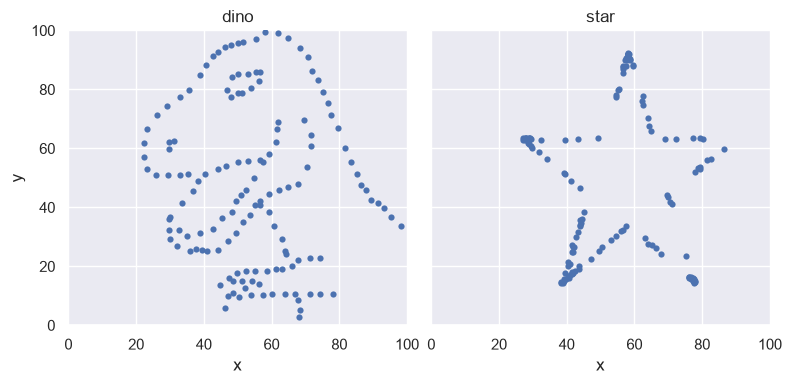

In [18]:
plot_pair(data=datasaurus_df, datasets=["dino", "star"])

### Debrief da armadilha

Cohen’s d não falhou: ele respondeu à pergunta para a qual foi construído, isto é, quão distantes estão as **médias** em unidades de desvio-padrão combinado. Aplicá-lo separadamente a `x` e `y` não descreve a forma conjunta dos pares `(x, y)`. A expressão "detector final" era, portanto, uma provocação pedagógica.

Os gráficos revelam estruturas radicalmente diferentes apesar de médias, desvios-padrão e correlações muito semelhantes. A lição não é abandonar resumos numéricos, mas confrontá-los com visualizações e escolher medidas adequadas à pergunta.

## Um segundo par para inspeção visual

In [19]:
bullseye = datasaurus_df.loc[
    datasaurus_df["dataset"] == "bullseye",
    ["x", "y"],
]

away = datasaurus_df.loc[
    datasaurus_df["dataset"] == "away",
    ["x", "y"],
]

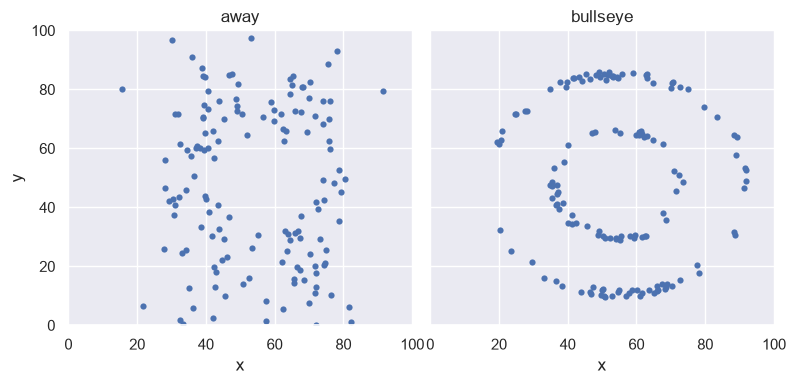

In [20]:
plot_pair(data=datasaurus_df, datasets=["bullseye", "away"])

## Extensão opcional: distância de energia e permutação

A estatística de energia compara as distâncias **entre** os dois grupos com as distâncias **dentro** de cada grupo. Ao usar os pontos bidimensionais completos, ela mira diferenças na distribuição conjunta de `(x, y)`, e não apenas diferenças marginais de média.

No teste abaixo, a hipótese nula afirma que os rótulos dos dois conjuntos são intercambiáveis. Em cada permutação, embaralhamos os rótulos, preservamos os tamanhos dos grupos e recalculamos a estatística. A semente torna o exemplo reprodutível.

> **Cuidado:** os conjuntos do Datasaurus foram construídos deliberadamente; não são uma amostra aleatória natural. O valor de *p* aqui é uma demonstração computacional sob a hipótese de intercambiabilidade, não uma justificativa automática para inferência sobre uma população.

In [21]:
from scipy.spatial.distance import cdist


def estatistica_energia(grupo_a, grupo_b):
    grupo_a = np.asarray(grupo_a, dtype=float)
    grupo_b = np.asarray(grupo_b, dtype=float)

    if grupo_a.ndim != 2 or grupo_b.ndim != 2:
        raise ValueError("Os grupos devem ser matrizes com uma linha por ponto.")
    if grupo_a.shape[1] != grupo_b.shape[1]:
        raise ValueError("Os pontos dos dois grupos devem ter a mesma dimensão.")

    distancia_entre = cdist(grupo_a, grupo_b).mean()
    distancia_em_a = cdist(grupo_a, grupo_a).mean()
    distancia_em_b = cdist(grupo_b, grupo_b).mean()

    return 2 * distancia_entre - distancia_em_a - distancia_em_b

In [22]:
def teste_permutacao_energia(grupo_a, grupo_b, repeticoes=999, semente=42):
    grupo_a = np.asarray(grupo_a, dtype=float)
    grupo_b = np.asarray(grupo_b, dtype=float)
    todos_os_pontos = np.vstack([grupo_a, grupo_b])
    tamanho_a = len(grupo_a)
    rng = np.random.default_rng(semente)

    observada = estatistica_energia(grupo_a, grupo_b)
    distribuicao_nula = np.empty(repeticoes)

    for indice in range(repeticoes):
        ordem = rng.permutation(len(todos_os_pontos))
        permutado_a = todos_os_pontos[ordem[:tamanho_a]]
        permutado_b = todos_os_pontos[ordem[tamanho_a:]]
        distribuicao_nula[indice] = estatistica_energia(
            permutado_a,
            permutado_b,
        )

    valor_p = (
        1 + np.count_nonzero(distribuicao_nula >= observada)
    ) / (repeticoes + 1)

    return observada, valor_p, distribuicao_nula

In [23]:
def obter_pontos(data, nome_do_conjunto):
    return (
        data.loc[
            data["dataset"] == nome_do_conjunto,
            ["x", "y"],
        ]
        .dropna()
        .to_numpy()
    )


pares = {
    "dino × star": (
        obter_pontos(datasaurus_df, "dino"),
        obter_pontos(datasaurus_df, "star"),
    ),
    "bullseye × away": (
        obter_pontos(datasaurus_df, "bullseye"),
        obter_pontos(datasaurus_df, "away"),
    ),
}

In [24]:
resultados_energia = {}

for nome, (grupo_a, grupo_b) in pares.items():
    resultados_energia[nome] = teste_permutacao_energia(
        grupo_a,
        grupo_b,
        repeticoes=999,
        semente=42,
    )

In [25]:
resumo_energia = pd.DataFrame(
    [
        {
            "comparação": nome,
            "estatística de energia": resultado[0],
            "valor de p (permutação)": resultado[1],
            "número de permutações": len(resultado[2]),
        }
        for nome, resultado in resultados_energia.items()
    ]
)

display(resumo_energia.round(4))

,comparação,estatística de energia,valor de p (permutação),número de permutações
0,dino × star,0.7932,0.211,999
1,bullseye × away,0.4195,0.554,999


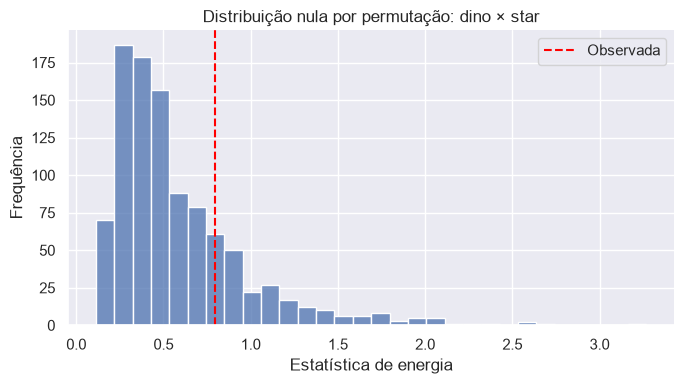

In [26]:
nome = "dino × star"
observada, _, distribuicao_nula = resultados_energia[nome]

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(distribuicao_nula, bins=30, ax=ax)
ax.axvline(observada, color="red", linestyle="--", label="Observada")
ax.set(
    title=f"Distribuição nula por permutação: {nome}",
    xlabel="Estatística de energia",
    ylabel="Frequência",
)
ax.legend()
sns.despine()
fig.tight_layout()
plt.show()

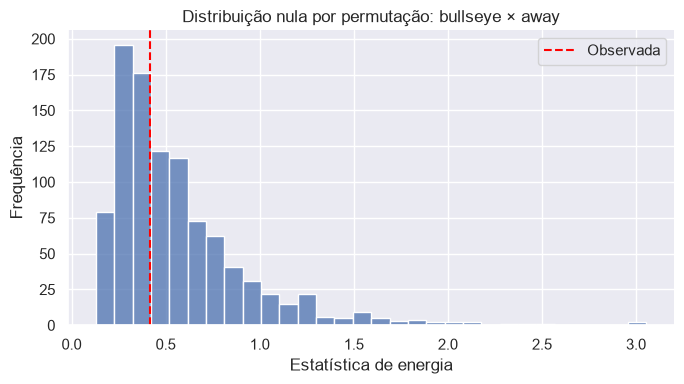

In [27]:
nome = "bullseye × away"
observada, _, distribuicao_nula = resultados_energia[nome]

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(distribuicao_nula, bins=30, ax=ax)
ax.axvline(observada, color="red", linestyle="--", label="Observada")
ax.set(
    title=f"Distribuição nula por permutação: {nome}",
    xlabel="Estatística de energia",
    ylabel="Frequência",
)
ax.legend()
sns.despine()
fig.tight_layout()
plt.show()

### Como interpretar esta extensão

Uma estatística observada distante da distribuição gerada por permutação indica incompatibilidade com a hipótese de rótulos intercambiáveis. O valor de *p* resume essa posição relativa; ele **não** mede o tamanho da diferença, não explica por que as formas diferem e não substitui a inspeção dos gráficos.

Nos dois pares examinados, os valores de *p* exibidos não são pequenos nos níveis convencionais. Isso é um resultado válido do procedimento especificado, não uma demonstração de que as figuras são iguais. O tamanho da amostra, a sensibilidade da estatística e a construção dos conjuntos importam; escolher outro par apenas porque produziu um valor menor seria uma análise pós-hoc.

Neste exemplo construído, a distância de energia é útil porque considera a distribuição conjunta. Em uma pesquisa real, o desenho amostral, a independência das observações e a plausibilidade da permutação precisariam ser justificados antes do teste.